### Martingale Posteriors for LLMs

In [1]:
from notebook_utils import modify_sys_path, get_src_dir_path, set_plot_style

modify_sys_path()
set_plot_style()

In [2]:
from src.dataset import load_dataset
from src.utils import ToyClassificationUtils
from src.prompt import ToyClassificationPrompt
from src.chat import chat_response_only

import os
import pandas as pd
import numpy as np
import torch
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

### Load Results

In [3]:
from src.martingale_posterior import quadratic_featurizer, cubic_featurizer
import torch
from csaps import csaps
from sklearn.svm import SVC

In [4]:
# get shots
import os
from src.utils import calculate_min_Va_by_KL_rank

feature_columns = ['x1']

def get_shots_df(results_directory, shots=15, num_valid_Va: int=5, feature_columns=['x1']) -> pd.DataFrame:
    # Load the results
    df_list = []
    for filename in os.listdir(get_src_dir_path(results_directory)):
        if f"results_{shots}_shot" in filename:
            save_data = pd.read_csv(get_src_dir_path(results_directory) + filename)
            df_list.append(save_data)
    
    for save_data in df_list:
        # z_data = calculate_min_Va_by_KL_threshold(z_data, threshold=0.005, forward_kl=True)
        save_data = calculate_min_Va_by_KL_rank(save_data, num_valid_Va=num_valid_Va, forward_kl=True, upper_bound_by_total_U=True)
    
    x_feature_list = []
    total_uncertainty_list = []

    for z_df in df_list:
        try:
            x_feature_list.append([z_df[f'x_{col}'].values[0] for col in feature_columns])
            total_uncertainty = z_df["H[p(y|x,D)]"].values[0]
            total_uncertainty_list.append(total_uncertainty)            
        except:
            pass
        
    # Create a dataframe from the lists
    data = {
            'total_uncertainty': total_uncertainty_list,
            }
    
    data = {**{f"x_{col}": [d[i] for d in x_feature_list] for i, col in enumerate(feature_columns)}, **data}

    shots_df = pd.DataFrame(data)

    shots_df = shots_df.sort_values(by=[f"x_{col}" for col in feature_columns])
    
    return shots_df

In [5]:
def compute_total_uncertainty(b0_list, b1_list, X: np.ndarray, seed=0, num_samples=100, probit_likelihood: bool= False, feature_interaction: str = "linear"):
    """
    Compute the total uncertainty based on the provided b0 and b1 lists.
    
    Args:
        b0_list (list): List of b0 values.
        b1_list (list): List of b1 values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Total uncertainty.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(b0_list)
    random_indices = rng.choice(len(b0_list), size=num_samples, replace=True)
    b0_samples = np.array(b0_list)[random_indices]
    b1_samples = np.array(b1_list)[random_indices]

    if feature_interaction == "quadratic":
        X = quadratic_featurizer(torch.tensor(X)).numpy()
        print(X.shape)
    elif feature_interaction == "cubic":
        X = cubic_featurizer(torch.tensor(X)).numpy()
    
    logits = b0_samples + X @ b1_samples.T
    if probit_likelihood:
        probabilities = torch.distributions.Normal(0, 1).cdf(torch.tensor(logits))
        probabilities = probabilities.numpy()
    else:
        probabilities = 1 / (1 + np.exp(-logits))

    mean_probability = np.mean(probabilities, axis=1)
    
    entropy = - mean_probability * np.log2(mean_probability + 10e-6) - (1 - mean_probability) * np.log2(1 - mean_probability + 10e-6)
    
    return entropy

In [6]:
def compute_aleatoric_uncertainty(b0_list, b1_list, X: np.ndarray, seed=0, num_samples=100, probit_likelihood: bool = False, feature_interaction: str = "linear"):
    """
    Compute the aleatoric uncertainty based on the provided b0 and b1 lists.
    
    Args:
        b0_list (list): List of b0 values.
        b1_list (list): List of b1 values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Aleatoric uncertainty.
    """
    
    rng = np.random.default_rng(seed)
    num_samples = len(b0_list)
    random_indices = rng.choice(len(b0_list), size=num_samples, replace=True)
    b0_samples = np.array(b0_list)[random_indices]
    b1_samples = np.array(b1_list)[random_indices]
    
    if feature_interaction == "quadratic":
        # X = np.hstack((X, X**2))
        X = quadratic_featurizer(torch.tensor(X)).numpy()
    elif feature_interaction == "cubic":
        X = cubic_featurizer(torch.tensor(X)).numpy()

    logits = b0_samples + X @ b1_samples.T
    
    if probit_likelihood:
        probabilities = torch.distributions.Normal(0, 1).cdf(torch.tensor(logits))
        probabilities = probabilities.numpy()
    else:
        probabilities = 1 / (1 + np.exp(-logits))

    entropy = - probabilities * np.log2(probabilities + 10e-6) - (1 - probabilities) * np.log2(1 - probabilities + 10e-6)

    return np.mean(entropy, axis=1)

In [7]:
def compute_total_uncertainty_kernel(data_list: list[tuple[np.ndarray, np.ndarray]], X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the total uncertainty using kernel smoothing based on the provided data list.
    
    Args:
        data_list (list): List of dataframes containing 'b0' and 'b1' values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Smoothed total uncertainty.
    """

    rng = np.random.default_rng(seed)
    num_samples = len(data_list)
    random_indices = rng.choice(len(data_list), size=num_samples, replace=True)
    X_samples = [data_list[random_index][0] for random_index in random_indices]
    y_samples = [data_list[random_index][1] for random_index in random_indices]

    # if feature_interaction == "quadratic":
    #     X = quadratic_featurizer(torch.tensor(X)).numpy()
    #     print(X.shape)
    #     X_samples = [quadratic_featurizer(torch.tensor(x)).numpy() for x in X_samples]
    # elif feature_interaction == "cubic":
    #     X = cubic_featurizer(torch.tensor(X)).numpy()
    #     X_samples = [cubic_featurizer(torch.tensor(x)).numpy() for x in X_samples]

    probability_list = []
    
    for x_s, y_s in zip(X_samples, y_samples):
        clf = SVC(probability=True, random_state=seed)
        clf.fit(x_s, y_s)
        probability = clf.predict_proba(X)[:, 1]
        probability_list.append(probability)

    probabilities = np.array(probability_list).T
    
    mean_probability = np.mean(probabilities, axis=1)
    
    entropy = - mean_probability * np.log2(mean_probability + 10e-6) - (1 - mean_probability) * np.log2(1 - mean_probability + 10e-6)
    
    return entropy

In [8]:
def compute_aleatoric_uncertainty_kernel(data_list: list[tuple[np.ndarray, np.ndarray]], X: np.ndarray, seed=0, num_samples=100):
    """
    Compute the total uncertainty using kernel smoothing based on the provided data list.
    
    Args:
        data_list (list): List of dataframes containing 'b0' and 'b1' values.
        X (np.ndarray): Input features.
        
    Returns:
        float: Smoothed total uncertainty.
    """

    rng = np.random.default_rng(seed)
    num_samples = len(data_list)
    random_indices = rng.choice(len(data_list), size=num_samples, replace=True)
    X_samples = [data_list[random_index][0] for random_index in random_indices]
    y_samples = [data_list[random_index][1] for random_index in random_indices]
    
    probability_list = []
    
    for x_s, y_s in zip(X_samples, y_samples):
        clf = SVC(probability=True, random_state=seed)
        clf.fit(x_s, y_s)
        probability = clf.predict_proba(X)[:, 1]
        probability_list.append(probability)

    probabilities = np.array(probability_list).T

    entropy = - probabilities * np.log2(probabilities + 10e-6) - (1 - probabilities) * np.log2(1 - probabilities + 10e-6)

    return np.mean(entropy, axis=1)

### 1D Logistic Regression

#### Parameters

In [124]:
feature_interaction = "cubic"
model_name = "qwen14b"


martingale_results_path = f'martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling/{feature_interaction}_logistic.csv'
llm_sample_dir = f'results/martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling/llm_samples/'

fig_save_directory = f'figures/martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling'


#### Plot Figures

In [125]:
if not os.path.exists(fig_save_directory):
    os.makedirs(fig_save_directory)

In [126]:
martingale_results_path = os.path.join(get_src_dir_path('results'), martingale_results_path)
results_df = pd.read_csv(martingale_results_path)

b0_list = results_df['b0'].tolist()
b1_list = results_df['b1'].apply(lambda x: eval(x)).tolist()

data_list = []
for filename in os.listdir(get_src_dir_path(llm_sample_dir)):
    try:
        data_frame = pd.read_csv(os.path.join(get_src_dir_path(llm_sample_dir), filename))
    except:
        continue
    x = data_frame['x1'].values.reshape(-1, 1)
    label = data_frame['label'].values
    if len(np.unique(label)) != 2:
        continue
    data_list.append((x, label))


In [127]:
X_array = np.arange(start=-15, stop=15, step=0.2)

In [128]:
total_uncertainty = compute_total_uncertainty(b0_list, b1_list, X_array.reshape(-1, 1), feature_interaction=feature_interaction, probit_likelihood=False)

aleatoric_uncertainty = compute_aleatoric_uncertainty(b0_list, b1_list, X_array.reshape(-1, 1), feature_interaction=feature_interaction, probit_likelihood=False)

/tmp/ipykernel_3791657/4081322017.py:31: RuntimeWarning: overflow encountered in exp
  probabilities = 1 / (1 + np.exp(-logits))
/tmp/ipykernel_3791657/3629454839.py:32: RuntimeWarning: overflow encountered in exp
  probabilities = 1 / (1 + np.exp(-logits))


In [129]:
total_uncertainty_kernel = compute_total_uncertainty_kernel(data_list, X_array.reshape(-1, 1))

aleatoric_uncertainty_kernel = compute_aleatoric_uncertainty_kernel(data_list, X_array.reshape(-1, 1))

In [130]:
empirical_results_directory = f'results/logistic_regression_3/{model_name}/experiment_2/'

empirical_results = get_shots_df(get_src_dir_path(empirical_results_directory), shots=15, num_valid_Va=5, feature_columns=['x1'])

In [131]:
D_data_path = os.path.join(get_src_dir_path('results'), f'martingale_posterior/logistic_regression_3/{model_name}/permutation_sampling/D_15.csv')
D_data = pd.read_csv(D_data_path)

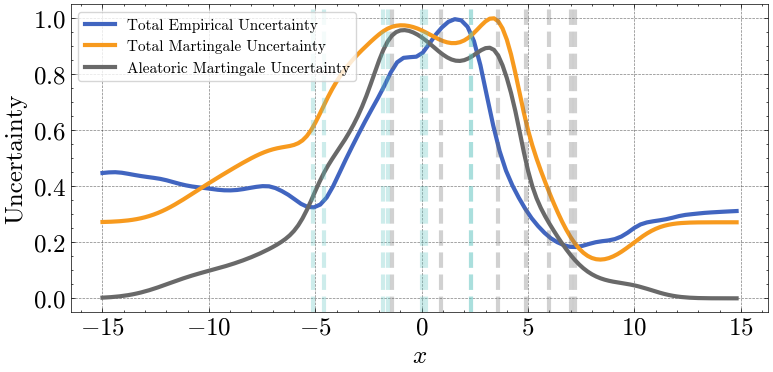

In [132]:
fig, ax = plt.subplots(figsize=(9, 4))

feature_column = 'x1'

x_grid = np.linspace(empirical_results[f'x_x1'].min(), empirical_results[f'x_x1'].max(), 100)
y_total_uncertainty = csaps(empirical_results[f'x_x1'], empirical_results['total_uncertainty'], smooth=0.85)
plt.plot(x_grid, y_total_uncertainty(x_grid), color='C0', linewidth = 3, label='Total Empirical Uncertainty')

sns.lineplot(x=X_array, y=total_uncertainty, ax=ax, label='Total Martingale Uncertainty', color='C4', linewidth=3)
sns.lineplot(x=X_array, y=aleatoric_uncertainty, ax=ax, label='Aleatoric Martingale Uncertainty', color='C3', linewidth=3)
# ax.set_title(rf'Logistic Regression: {feature_interaction.capitalize()} Features')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Uncertainty')

label_0_seen = True
label_1_seen = True
for i, row in D_data.iterrows():
    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y = 0$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C2', linestyle='--', linewidth=3, alpha=0.3, label=label_string)
    else:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y = 1$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C3', linestyle='--', linewidth=3, alpha=0.3, label=label_string)

plt.legend(fontsize=11, framealpha=0.8)

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}.pdf', dpi=90, bbox_inches='tight', pad_inches=0.01)

plt.show()

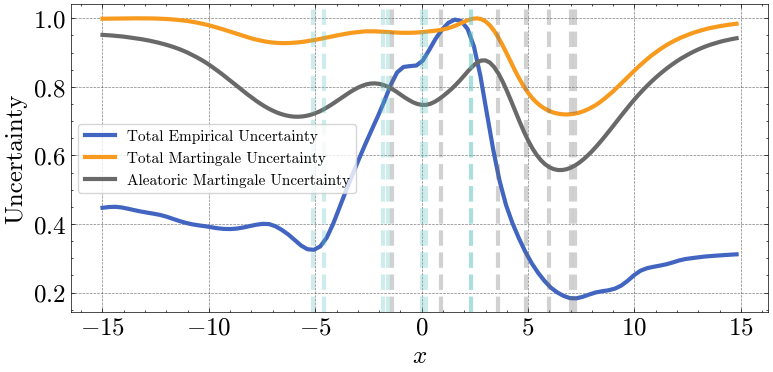

In [133]:
fig, ax = plt.subplots(figsize=(9, 4))

feature_column = 'x1'

x_grid = np.linspace(empirical_results[f'x_x1'].min(), empirical_results[f'x_x1'].max(), 100)
y_total_uncertainty = csaps(empirical_results[f'x_x1'], empirical_results['total_uncertainty'], smooth=0.85)
plt.plot(x_grid, y_total_uncertainty(x_grid), color='C0', linewidth = 3, label='Total Empirical Uncertainty')

sns.lineplot(x=X_array, y=total_uncertainty_kernel, ax=ax, label='Total Martingale Uncertainty', color='C4', linewidth=3)
sns.lineplot(x=X_array, y=aleatoric_uncertainty_kernel, ax=ax, label='Aleatoric Martingale Uncertainty', color='C3', linewidth=3)
# ax.set_title(rf'Logistic Regression: {feature_interaction.capitalize()} Features')
ax.set_xlabel(r'$x$')
ax.set_ylabel('Uncertainty')

label_0_seen = True
label_1_seen = True
for i, row in D_data.iterrows():
    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y = 0$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C2', linestyle='--', linewidth=3, alpha=0.3, label=label_string)
    else:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y = 1$'
        else:
            label_string = None
        plt.axvline(x=row[feature_column], color='C3', linestyle='--', linewidth=3, alpha=0.3, label=label_string)

plt.legend(fontsize=11, framealpha=0.8)

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_kernel.pdf', dpi=90, bbox_inches='tight', pad_inches=0.01)

plt.show()

In [134]:
empirical_total_uncertainty = empirical_results['total_uncertainty'].values
martingale_total_uncertainty = total_uncertainty

L2_norm = np.trapz(np.abs(empirical_total_uncertainty - martingale_total_uncertainty)**2, x=X_array)
print(f"L2 norm: {L2_norm}")

L2 norm: 1.0001086053312829


In [135]:
empirical_total_uncertainty = empirical_results['total_uncertainty'].values
martingale_total_uncertainty_kernel = total_uncertainty_kernel

L2_norm_kernel = np.trapz(np.abs(empirical_total_uncertainty - martingale_total_uncertainty_kernel)**2, x=X_array)
print(f"L2 norm: {L2_norm_kernel}")

L2 norm: 7.823112654832186


### 2D Moons Plots

#### Set Up

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import scipy.integrate as spi

In [10]:
feature_columns = ['x1', 'x2']
feature_ranges = [[-3, 3], [-3, 3]]
feature_increment = 0.1

def get_grid_points(feature_columns, feature_ranges, feature_increment):
    """
    Generate grid points for the given feature columns and ranges.
    
    Args:
        feature_columns (list): List of feature column names.
        feature_ranges (list): List of ranges for each feature column.
        feature_increment (float): Increment for generating grid points.
        
    Returns:
        np.ndarray: Grid points in the form of a 2D array.
    """
    grid_points = []
    for i, col in enumerate(feature_columns):
        grid_points.append(np.arange(feature_ranges[i][0], feature_ranges[i][1] + feature_increment, feature_increment))
    
    return np.array(np.meshgrid(*grid_points)).T.reshape(-1, len(feature_columns))

X = get_grid_points(feature_columns, feature_ranges, feature_increment)

#### Parameters

In [178]:
feature_interaction = "kernel"
model_name = "qwen14b"


martingale_results_path = f'martingale_posterior/moons/{model_name}/permutation_sampling_2/{feature_interaction}_logistic.csv'
llm_sample_dir = f'results/martingale_posterior/moons/{model_name}/permutation_sampling_2/llm_samples/'
fig_save_directory = f'figures/martingale_posterior/moons/{model_name}/permutation_sampling_2'


#### Generate Figures - Polynomial Features

In [179]:
if not os.path.exists(fig_save_directory):
    os.makedirs(fig_save_directory)

In [180]:



if feature_interaction == "kernel":
    data_list = []
    for filename in os.listdir(get_src_dir_path(llm_sample_dir)):
        try:
            data_frame = pd.read_csv(os.path.join(get_src_dir_path(llm_sample_dir), filename))
        except:
            continue
        x1 = data_frame['x1'].values
        x2 = data_frame['x2'].values
        x = np.vstack((x1, x2)).T
        label = data_frame['label'].values
        if len(np.unique(label)) != 2:
            continue
        data_list.append((x, label))
        
    total_uncertainty_grid = compute_total_uncertainty_kernel(data_list, X, seed=0, num_samples=100)
    
    aleatoric_uncertainty_grid = compute_aleatoric_uncertainty_kernel(data_list, X, seed=0, num_samples=100)
    
else:
    martingale_results_path = os.path.join(get_src_dir_path('results'), martingale_results_path)
    results_df = pd.read_csv(martingale_results_path)

    b0_list = results_df['b0'].tolist()
    b1_list = results_df['b1'].apply(lambda x: eval(x)).tolist()
    
    total_uncertainty_grid = compute_total_uncertainty(b0_list, b1_list, X, seed=0, num_samples=100, probit_likelihood=False, feature_interaction=feature_interaction)
    
    aleatoric_uncertainty_grid = compute_aleatoric_uncertainty(b0_list, b1_list, X, seed=0, num_samples=100, probit_likelihood=False, feature_interaction=feature_interaction)

In [181]:
import colorsys

def brighter_colour(colour, amount=0.5):
    rgb = mpl.colors.to_rgb(colour)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # l = min(1, l + amount)
    s = min(1, s + amount)
    new_rgb = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex(new_rgb)

In [182]:
dim = int(np.sqrt(total_uncertainty_grid.shape)[0])

In [183]:
D_data_path = os.path.join(get_src_dir_path('results'), f'martingale_posterior/moons/{model_name}/permutation_sampling_2/D_30.csv')
D_data = pd.read_csv(D_data_path)

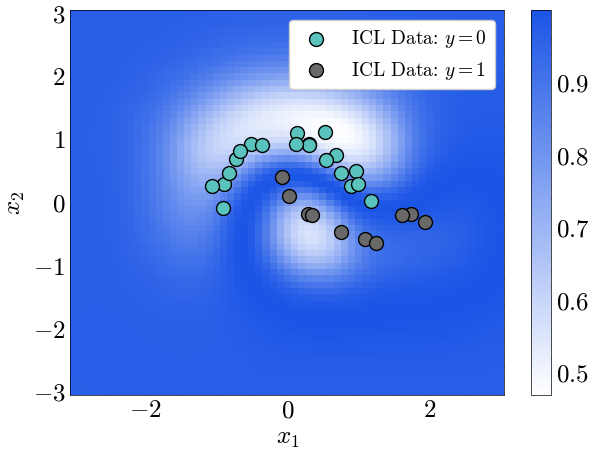

In [184]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C0', ['white', brighter_colour('C0',0.3)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  total_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend(loc='upper right')

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_total.pdf', dpi=50, bbox_inches='tight', pad_inches=0.01)

plt.show()

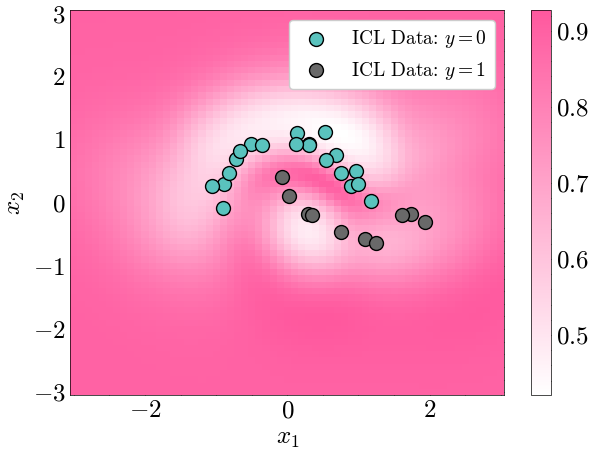

In [185]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C1', ['white', brighter_colour('C1',0.3)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  aleatoric_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
# ax.set_title(r'Cubic Features Aleatoric Uncertainty: Martingale Posterior ($|\mathcal{D}|$ = 15)')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend(loc='upper right')

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_aleatoric.pdf', dpi=50, bbox_inches='tight', pad_inches=0.01)

plt.show()

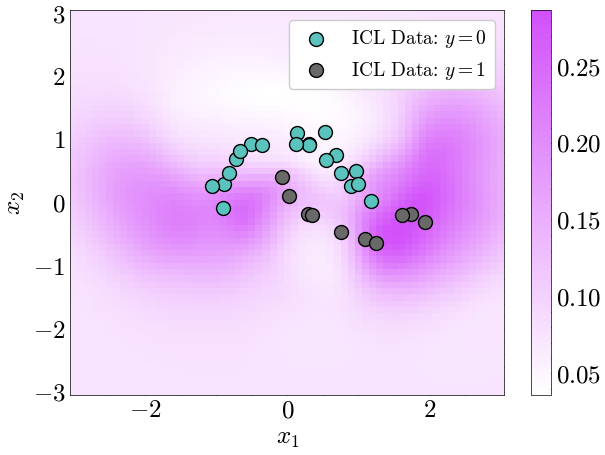

In [186]:
# plot heatmap of total uncertainty grid with grid_points as x and y axes
epistemic_uncertainty_grid = total_uncertainty_grid - aleatoric_uncertainty_grid

custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('white_to_C5', ['white', brighter_colour('C5',0.5)])

fig, ax = plt.subplots(figsize=(7, 5))
c = ax.pcolormesh(X[:, 0].reshape(dim, dim), 
                  X[:, 1].reshape(dim, dim),
                  epistemic_uncertainty_grid.reshape(dim, dim),
                  cmap=custom_cmap,
                  shading='auto')
plt.colorbar(c, ax=ax)
# ax.set_title(r'Cubic Features Aleatoric Uncertainty: Martingale Posterior ($|\mathcal{D}|$ = 15)')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')

label_0_seen = False
label_1_seen = False
label_2_seen = False
for i, row in D_data.iterrows():

    if row['label'] == 0:
        if not label_0_seen:
            label_0_seen = True
            label_string = r'ICL Data: $y=0$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C2', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 1:
        if not label_1_seen:
            label_1_seen = True
            label_string = r'ICL Data: $y=1$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C3', edgecolor='black', s=100, alpha=1, label=label_string)
    if row['label'] == 2:
        if not label_2_seen:
            label_2_seen = True
            label_string = r'ICL Data: $y=2$'
        else:
            label_string = None
        ax.scatter(row['x1'], row['x2'], c='C4', edgecolor='black', s=100, alpha=1, label=label_string)

plt.legend(loc='upper right')

plt.savefig(f'{fig_save_directory}/martingale_logistic_regression_{model_name}_{feature_interaction}_epistemic.pdf', dpi=50, bbox_inches='tight', pad_inches=0.01)

plt.show()

In [187]:
empirical_results_directory = f'results/moons/{model_name}/experiment_4/'

empirical_results = get_shots_df(get_src_dir_path(empirical_results_directory), shots=30, num_valid_Va=5, feature_columns=['x1', 'x2'])

In [188]:
martingale_total_uncertainty_df = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'total_uncertainty': total_uncertainty_grid,
})

In [189]:
for i, row in empirical_results.iterrows():
    approx_uncertainty = martingale_total_uncertainty_df[(abs(martingale_total_uncertainty_df['x1'] - row['x_x1']) < 0.001) & (abs(martingale_total_uncertainty_df['x2'] - row['x_x2']) < 0.001)]['total_uncertainty'].values[0]
    empirical_results.at[i, 'martingale_uncertainty'] = approx_uncertainty

In [190]:
empirical_results

,x_x1,x_x2,total_uncertainty,martingale_uncertainty
260,-1.5,-1.0,0.99858,0.919461
227,-1.5,-0.8,0.94592,0.899477
211,-1.5,-0.6,0.93866,0.877418
285,-1.5,-0.4,0.84126,0.855914
233,-1.5,-0.2,0.80567,0.835281
...,...,...,...,...
153,2.3,1.0,0.89081,0.972107
29,2.3,1.2,0.90745,0.967524
90,2.3,1.4,0.89037,0.965635
184,2.3,1.6,0.85636,0.965449


In [191]:
empirical_results['squared_error'] = (empirical_results['total_uncertainty'] - empirical_results['martingale_uncertainty'])**2

In [192]:
# Simpsons rule twice to approximate integral on 2D grid

L2_norm_columns = [spi.simpson(empirical_results[empirical_results['x_x1'] == x]['squared_error'], x=empirical_results[empirical_results['x_x1'] == x]['x_x2']) for x in empirical_results['x_x1'].unique()]
L2_norm = spi.simpson(L2_norm_columns, x=empirical_results['x_x1'].unique())

#### L2 Norm

In [27]:
round(L2_norm, 3)

1.515